# Biome estimation exercise

Below you will 

In [1]:
#%pip install cartopy


In [2]:
#%pip install ISLP

In [3]:
#%pip install shap

In [4]:
import pandas as pd
import cartopy.crs as ccrs # Enables geographic mapping, e.g., drawing coastlines, etc
import matplotlib.pyplot as plt


proj = ccrs.PlateCarree()

In [5]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]
biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [6]:
countries = pd.read_csv('gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep='\\s+')
countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


In [7]:
# Biome obs from Haxeltine & Prentice, 1996
df = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
df.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [8]:
biome_data = df[['Lon', 'Lat', 'Biome_obs']]
biome_data['Biome_obs'].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

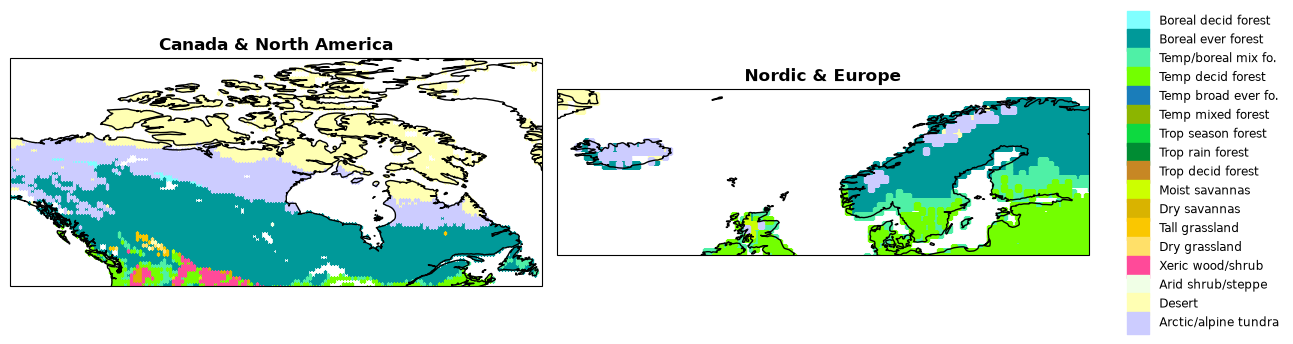

In [9]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(13, 5), subplot_kw=dict(projection=ccrs.PlateCarree())
)

ax1.set_extent([-141, -52, 45, 83], crs=ccrs.PlateCarree())
ax1.set_title('Canada & North America', fontsize=12, fontweight='bold')
ax1.coastlines()

ax2.set_extent([-26, 32, 54, 72], crs=ccrs.PlateCarree())
ax2.set_title('Nordic & Europe', fontsize=12, fontweight='bold')
ax2.coastlines()

for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i + 1]
    if not biome.empty:
        ax1.scatter(
            biome['Lon'],
            biome['Lat'],
            color=biome_rgbs[i],
            s=1,
            marker='s',
        )
        ax2.scatter(
            biome['Lon'],
            biome['Lat'],
            color=biome_rgbs[i],
            s=15,
            marker='s',
            label=name,
        )


ax2.legend(
    markerscale=4,
    loc='center left',
    bbox_to_anchor=(1.05, 0.5),
    fontsize=8.5,
    frameon=False,
)

plt.tight_layout()
plt.show()

# Start your data formatting below. Good luck!

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, mean_squared_error, r2_score, mean_absolute_error

Data Visualization

Variables' distribution in EU 

In [11]:
df_pre   = pd.read_csv('data/Predaymean1961_1990_stats.csv')
df_tmp   = pd.read_csv('data/Tmpdaymean1961_1990_stats.csv')
df_tmax  = pd.read_csv('data/Tmaxdaymean1961_1990_stats.csv')
df_tmin  = pd.read_csv('data/Tmindaymean1961_1990_stats.csv')
df_tswrf = pd.read_csv('data/Tswrfdaymean1961_1990_stats.csv')

def prepare_df(df, prefix):

    df = df.rename(columns={'lon': 'Lon', 'lat': 'Lat', 'longitude': 'Lon', 'latitude': 'Lat'})
    rename_dict = {col: f"{prefix}_{col}" for col in df.columns if col not in ['Lon', 'Lat']}
    return df.rename(columns=rename_dict)

df_pre   = prepare_df(df_pre, 'pre')
df_tmp   = prepare_df(df_tmp, 'tmp')
df_tmax  = prepare_df(df_tmax, 'tmax')
df_tmin  = prepare_df(df_tmin, 'tmin')
df_tswrf = prepare_df(df_tswrf, 'tswrf')

climate_dfs = [df_pre, df_tmp, df_tmax, df_tmin, df_tswrf]
df_climate = climate_dfs[0]
for df in climate_dfs[1:]:
    df_climate = pd.merge(df_climate, df, on=['Lon', 'Lat'], how='inner')

df_target = pd.read_csv('data/LPJ-GUESS_output_BERN1.csv')
gridlist  = pd.read_csv('gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep=r'\s+')

for df in [df_target, gridlist]:
    df.rename(columns={'lon': 'Lon', 'lat': 'Lat', 'longitude': 'Lon', 'latitude': 'Lat'}, inplace=True)

df_merged = pd.merge(df_climate, df_target, on=['Lon', 'Lat'], how='inner')
df_merged = pd.merge(df_merged, gridlist, on=['Lon', 'Lat'], how='inner')

to_delete= ['pre_SpringMedian', 'pre_SpringStd','pre_SummerMedian', 'pre_SummerStd', 'pre_FallMedian', 'pre_FallStd', 'pre_WinterMedian', 'pre_WinterStd','tmp_SpringMedian', 'tmp_SpringStd','tmp_SummerMedian', 'tmp_SummerStd', 'tmp_FallMedian', 'tmp_FallStd','Pan_2007','tmp_WinterMedian', 'tmp_WinterStd', 'tmax_SpringMedian', 'tmax_SpringStd', 'tmax_SummerMedian', 'tmax_SummerStd', 'tmax_FallMedian', 'tmax_FallStd', 'tmax_WinterMedian', 'tmax_WinterStd', 'tmin_SpringMedian', 'tmin_SpringStd', 'tmin_SummerMedian', 'tmin_SummerStd', 'tmin_FallMedian', 'tmin_FallStd', 'tmin_WinterMedian', 'tmin_WinterStd', 'tswrf_SpringMedian', 'tswrf_SpringStd', 'tswrf_SummerMedian', 'tswrf_SummerStd', 'tswrf_FallMedian', 'tswrf_FallStd', 'tswrf_WinterMedian', 'tswrf_WinterStd']
df_merged = df_merged.drop(columns=to_delete)

df_canada = df_merged[df_merged['ISO3'] == 'CAN']
df_australia = df_merged[df_merged['ISO3'] == 'AUS']

europe_iso = [
  #  'SWE', 'NOR', 'FIN', 'DNK', 'ISL', 'GBR', 'IRL', 'DEU', 'FRA', 'ESP', 
 #  'PRT', 'ITA', 'NLD', 'BEL', 'CHE', 'AUT', 'POL', 'CZE', 'SVK', 'HUN', 
   # 'ROU', 'BGR', 'GRC', 'EST', 'LVA', 'LTU', 'BLR', 'UKR', 'HRV', 'SRB'



   'SWE', 'NOR', 'FIN', 'DNK', 'ISL'
]
df_europe = df_merged[df_merged['ISO3'].isin(europe_iso)]

south_america_iso = [
    'BRA', 'ARG', 'COL', 'PER', 'VEN', 'CHL', 
    'ECU', 'BOL', 'PRY', 'URY', 'GUY', 'SUR'
]
df_south_america = df_merged[df_merged['ISO3'].isin(south_america_iso)]

print(f"Europe grid count: {len(df_europe)}")
print(f"Canada grid count: {len(df_canada)}")
print(f"South America grid count: {len(df_south_america)}")
print(f"Australia grid count: {len(df_australia)}")

Europe grid count: 925
Canada grid count: 6499
South America grid count: 6190
Australia grid count: 2826


In [12]:
df_europe.head()

,Lon,Lat,pre_SpringMean,pre_SummerMean,pre_FallMean,pre_WinterMean,tmp_SpringMean,tmp_SummerMean,tmp_FallMean,tmp_WinterMean,...,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs,GFED-region,ISO3,UN,Ecoregion
45,10.25,62.25,1.0472,1.3020,2.3092,1.4383,264.44,276.09,280.66,268.64,...,6.446,18.294,28.623,2,2,2,6,NOR,578,11
50,28.25,64.25,1.1117,1.5451,2.4035,1.6442,262.43,279.57,285.03,269.05,...,9.638,18.268,31.691,2,2,2,6,FIN,246,6
73,19.75,68.75,1.1180,1.1252,1.9308,1.3779,261.56,274.35,280.43,266.17,...,0.142,0.803,14.560,11,11,18,6,NOR,578,11
78,26.75,70.25,1.3891,1.2469,1.8498,1.6613,262.21,275.18,281.42,267.01,...,4.464,11.122,22.390,1,1,2,6,NOR,578,11
161,23.75,70.25,1.7296,1.4463,1.9715,2.1576,264.94,274.86,281.09,268.96,...,4.303,10.279,37.908,1,1,2,6,NOR,578,11


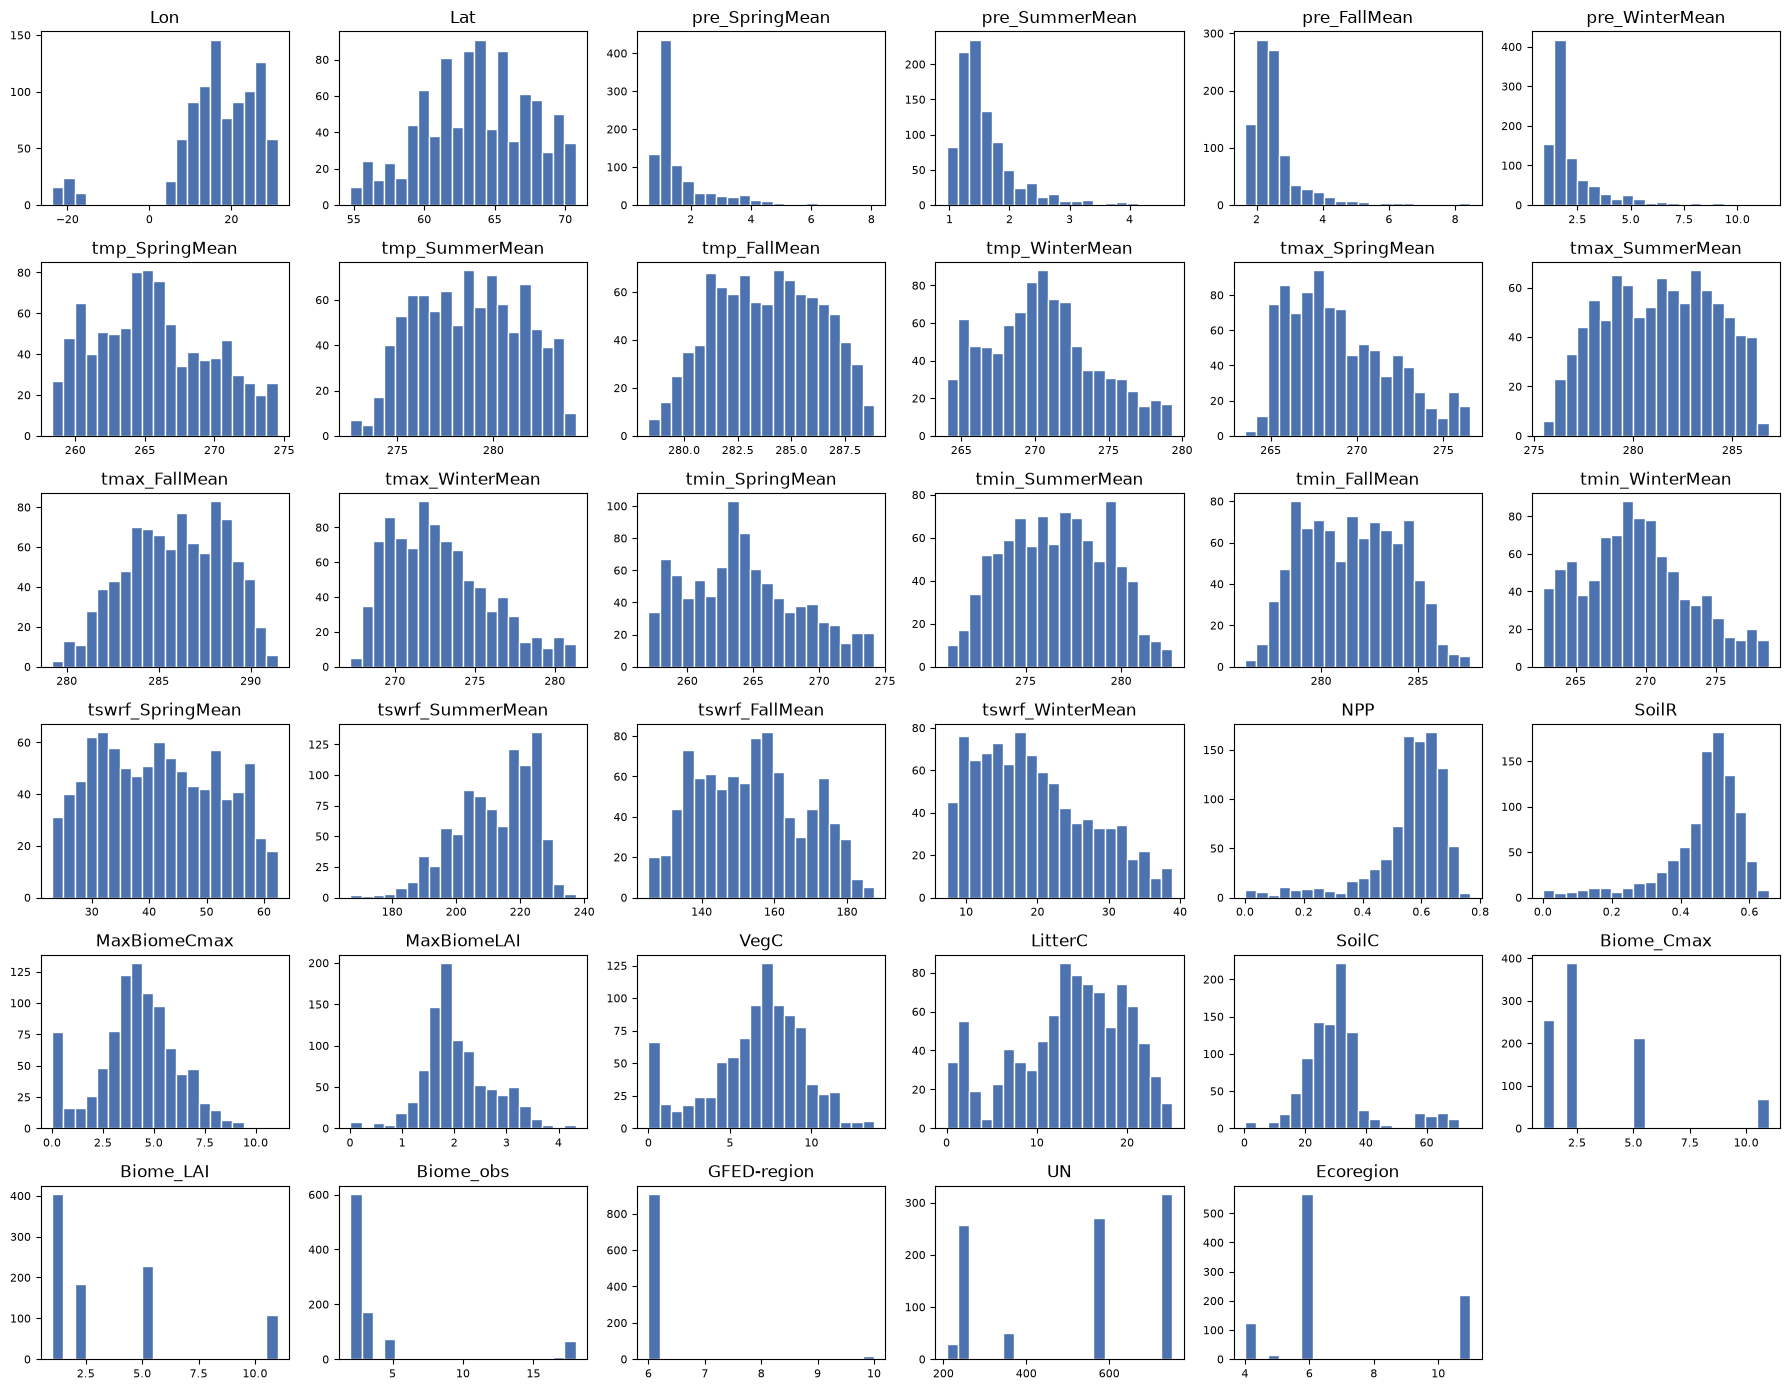

In [13]:
df_europe.hist(
    figsize=(18, 14), 
    bins=20, 
    xlabelsize=8, 
    ylabelsize=8,
    color='#4C72B0',
    edgecolor='white',
    grid=False
)

plt.tight_layout()
plt.show()

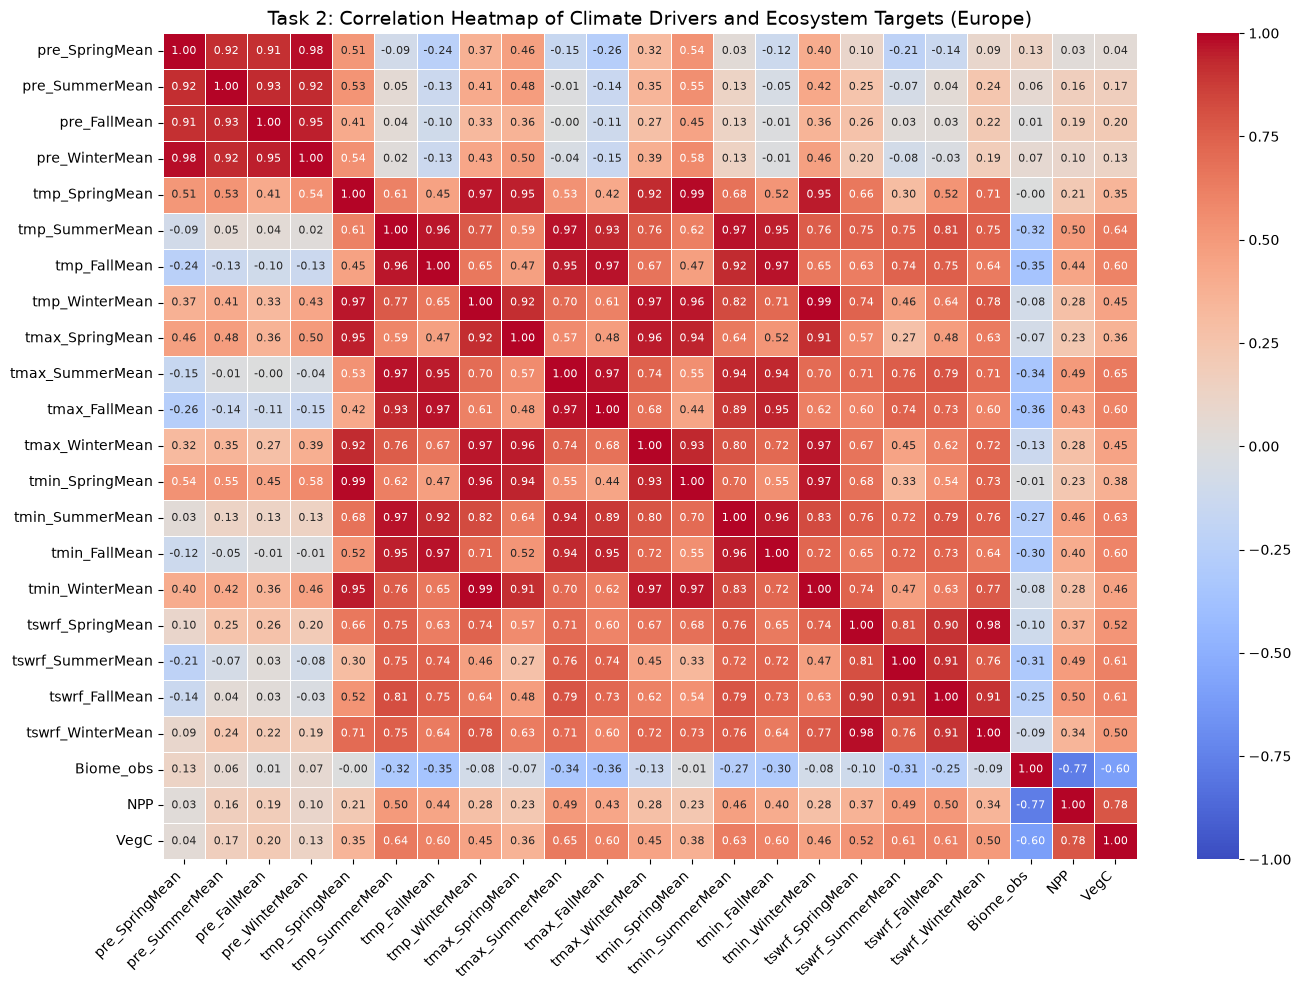

In [14]:
#For correlation_matrix
NUMERIC_FEATURES_AND_TARGETS = [

    'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean',

    'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean',

    'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean',

    'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean',

    'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean',
    
    'Biome_obs', 'NPP', 'VegC'
]


correlation_matrix = df_europe[NUMERIC_FEATURES_AND_TARGETS].corr()


plt.figure(figsize=(14, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-1, vmax=1,
    annot_kws={"size": 8}
)

plt.title('Task 2: Correlation Heatmap of Climate Drivers and Ecosystem Targets (Europe)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

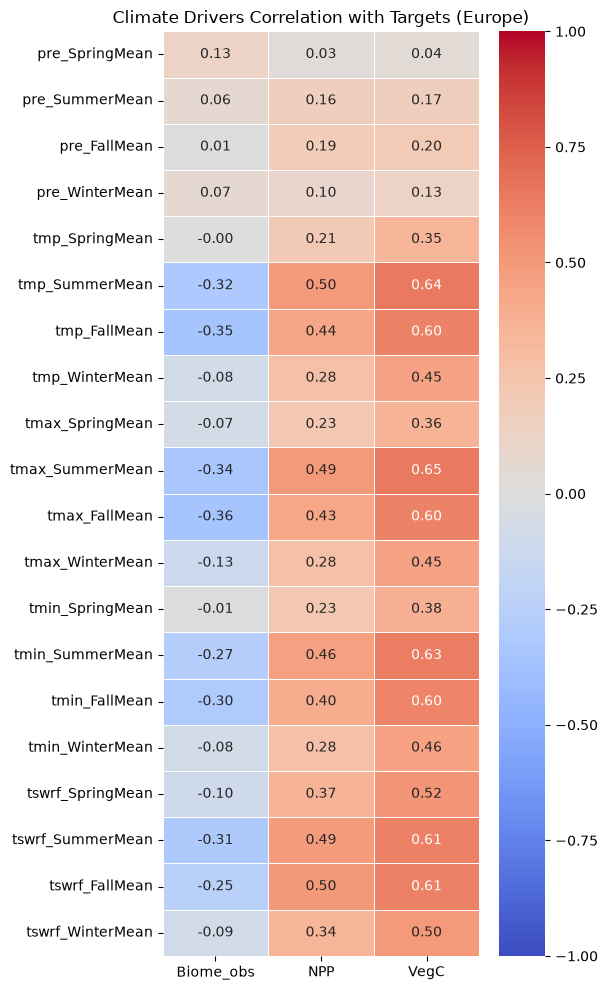

In [15]:
feature_cols = [
    'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean',
    'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean',
    'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean',
    'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean',
    'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean'
]
target_cols = ['Biome_obs', 'NPP', 'VegC']

sub_corr = df_europe[feature_cols + target_cols].corr().loc[feature_cols, target_cols]

plt.figure(figsize=(6, 10))
sns.heatmap(
    sub_corr, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5, 
    vmin=-1, vmax=1
)

plt.title('Climate Drivers Correlation with Targets (Europe)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Extract absolute correlation values for Biome_obs and sort descending
#biome_corr_sorted = sub_corr['Biome_obs'].abs().sort_values(ascending=False)

#print("==================================================")
#print("  Top 5 Most Influential Climate Drivers for Biome_obs")
#print("==================================================")
#top5_biome = sub_corr.loc[biome_corr_sorted.index[:5], ['Biome_obs']]
#print(top5_biome)
#print("\n")

# Extract absolute correlation values for NPP and sort descending
#npp_corr_sorted = sub_corr['NPP'].abs().sort_values(ascending=False)

#print("==================================================")
#print("  Top 5 Most Influential Climate Drivers for NPP")
#print("==================================================")
#top5_npp = sub_corr.loc[npp_corr_sorted.index[:5], ['NPP']]
#print(top5_npp)

# Extract absolute correlation values for VegC and sort descending
#vegc_corr_sorted = sub_corr['VegC'].abs().sort_values(ascending=False)

#print("==================================================")
#print("  Top 5 Most Influential Climate Drivers for VegC")
#print("==================================================")
#top5_vegc = sub_corr.loc[vegc_corr_sorted.index[:5], ['VegC']]
#print(top5_vegc)

In [17]:
del df_europe['ISO3']
del df_canada['ISO3']
del df_australia['ISO3']
del df_south_america['ISO3']

In [18]:
#data preparation

file_path = "data/soilmap.dat"
df_soil = pd.read_csv(file_path, sep=r'\s+')

df_europe = df_europe.copy()
df_canada = df_canada.copy()
df_australia = df_australia.copy()
df_south_america = df_south_america.copy()

precision = 4
#europe
df_europe['lon_round'] = df_europe['Lon'].round(precision)
df_europe['lat_round'] = df_europe['Lat'].round(precision)

df_canada['lon_round'] = df_canada['Lon'].round(precision)
df_canada['lat_round'] = df_canada['Lat'].round(precision)

df_australia['lon_round'] = df_australia['Lon'].round(precision)
df_australia['lat_round'] = df_australia['Lat'].round(precision)

df_south_america['lon_round'] = df_south_america['Lon'].round(precision)
df_south_america['lat_round'] = df_south_america['Lat'].round(precision)


df_soil['lon_round'] = df_soil['lon'].round(precision)
df_soil['lat_round'] = df_soil['lat'].round(precision)


soil_cols = ['lon_round', 'lat_round', 'clay', 'silt', 'sand', 'orgC', 'pH', 'CN']

soil_cols = [col for col in soil_cols if col in df_soil.columns]


df_europe = pd.merge(
    df_europe,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)

df_canada = pd.merge(
    df_canada,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)

df_australia = pd.merge(
    df_australia,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)

df_south_america = pd.merge(
    df_south_america,
    df_soil[soil_cols],
    on=['lon_round', 'lat_round'],
    how='left'
)


df_europe.drop(columns=['lon_round', 'lat_round'], inplace=True)
df_canada.drop(columns=['lon_round', 'lat_round'], inplace=True)
df_australia.drop(columns=['lon_round', 'lat_round'], inplace=True)
df_south_america.drop(columns=['lon_round', 'lat_round'], inplace=True)


In [19]:
#df_canada.dtypes.to_frame(name='Data_Type')

In [20]:
# Section 3 binary classification
forest_codes = [2]
# 
df_europe['is_forest'] = df_europe['Biome_obs'].isin(forest_codes).astype(int)
df_canada['is_forest'] = df_canada['Biome_obs'].isin(forest_codes).astype(int)
df_australia['is_forest'] = df_australia['Biome_obs'].isin(forest_codes).astype(int)
df_south_america['is_forest'] = df_south_america['Biome_obs'].isin(forest_codes).astype(int)


print("\n ratio of 'is_BEforest'in Europe：")
print(df_europe['is_forest'].value_counts())


 ratio of 'is_BEforest'in Europe：
is_forest
1    603
0    322
Name: count, dtype: int64


In [21]:
#Train europe model 

df_clean = df_europe.drop(columns=['clay_y', 'silt_y', 'sand_y', 'orgC_y', 'pH_y', 'CN_y'],errors='ignore').copy()
df_clean.rename(columns={
    'clay_x': 'clay', 'silt_x': 'silt', 'sand_x': 'sand',
    'orgC_x': 'orgC', 'pH_x': 'pH', 'CN_x': 'CN'
}, inplace=True)

drop_cols = [
    'is_forest', 
    'Biome_obs',  
    'Biome_Cmax', 
    'Biome_LAI', 
    'GFED-region', 
    'UN', 
    'Ecoregion', 
    'Lon', 'Lat' ,
    #add ignorance here

 #   'pre_WinterMean','tmp_WinterMean','tmax_SpringMean','tmax_WinterMean','tmin_SpringMean','tmin_WinterMean',
#'tmp_FallMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmin_SummerMean','tmin_FallMean','SoilC'
]


X = df_clean.drop(columns=drop_cols)
y = df_clean['is_forest']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y 
)


print(f"Feature list({X.shape[1]} ):")
print(list(X.columns))

print(f"\ntraining set: {X_train.shape[0]}, validation set: {X_val.shape[0]}")
print("\n BE forest ratio in training set:", round(y_train.mean(), 3))
print(" BE forest ratio in validation set:", round(y_val.mean(), 3))

Feature list(33 ):
['pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean', 'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean', 'tmax_SpringMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmax_WinterMean', 'tmin_SpringMean', 'tmin_SummerMean', 'tmin_FallMean', 'tmin_WinterMean', 'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean', 'NPP', 'SoilR', 'MaxBiomeCmax', 'MaxBiomeLAI', 'VegC', 'LitterC', 'SoilC', 'clay', 'silt', 'sand', 'orgC', 'pH', 'CN']

training set: 740, validation set: 185

 BE forest ratio in training set: 0.651
 BE forest ratio in validation set: 0.654


In [22]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_val)

print("accuracy:", accuracy_score(y_val, y_pred))
print("\n classification prediction:")
print(classification_report(y_val, y_pred, target_names=['is not BEforest (0)', 'is BEforest (1)']))

accuracy: 0.9891891891891892

 classification prediction:
                     precision    recall  f1-score   support

is not BEforest (0)       1.00      0.97      0.98        64
    is BEforest (1)       0.98      1.00      0.99       121

           accuracy                           0.99       185
          macro avg       0.99      0.98      0.99       185
       weighted avg       0.99      0.99      0.99       185



In [23]:
# European model validation on Canada

df_can_test = df_canada.copy()
df_aus_test = df_australia.copy()
df_sou_test = df_south_america.copy()
df_can_test = df_canada.copy()

if 'clay_y' in df_can_test.columns:
    df_can_test = df_can_test.drop(columns=['clay_y', 'silt_y', 'sand_y', 'orgC_y', 'pH_y', 'CN_y'])
df_can_test.rename(columns={'clay_x': 'clay', 'silt_x': 'silt', 'sand_x': 'sand', 'orgC_x': 'orgC', 'pH_x': 'pH', 'CN_x': 'CN'}, inplace=True)

forest_codes = [2]
df_can_test['is_forest'] = df_can_test['Biome_obs'].isin(forest_codes).astype(int)

X_canada = df_can_test[X_train.columns]
y_canada = df_can_test['is_forest']

y_pred_canada = rf_model.predict(X_canada)

print("=" * 50)
print("       Effects of Northern Europe-trained model on Canada       ")
print("=" * 50)
print(classification_report(y_canada, y_pred_canada, target_names=['is not BEforest (0)', 'is BEforest (1)']))

       Effects of Northern Europe-trained model on Canada       
                     precision    recall  f1-score   support

is not BEforest (0)       0.81      0.98      0.89      3608
    is BEforest (1)       0.97      0.71      0.82      2891

           accuracy                           0.86      6499
          macro avg       0.89      0.84      0.85      6499
       weighted avg       0.88      0.86      0.86      6499



In [24]:
# European model features importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("=" * 50)
print("              Top 10 important features             ")
print("=" * 50)
print(importances.head(10).round(4))

top10_features = importances.head(10).index.tolist()

rf_small = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_small.fit(X_train[top10_features], y_train)

y_pred_small = rf_small.predict(X_val[top10_features])
print("\n accuracy with a model trained by top 10 features:", round((y_pred_small == y_val).mean(), 4))

              Top 10 important features             
tmp_SummerMean     0.1104
tmp_FallMean       0.1067
tmin_SummerMean    0.0964
MaxBiomeCmax       0.0852
tmin_FallMean      0.0800
tmax_SummerMean    0.0738
VegC               0.0625
LitterC            0.0581
NPP                0.0534
tmax_FallMean      0.0452
dtype: float64

 accuracy with a model trained by top 10 features: 1.0


In [25]:
# additional part
df_aus_test = df_australia.copy()

if 'clay_y' in df_aus_test.columns:
    df_aus_test = df_aus_test.drop(columns=['clay_y', 'silt_y', 'sand_y', 'orgC_y', 'pH_y', 'CN_y'])
df_aus_test.rename(columns={
    'clay_x': 'clay', 'silt_x': 'silt', 'sand_x': 'sand',
    'orgC_x': 'orgC', 'pH_x': 'pH', 'CN_x': 'CN'
}, inplace=True)

forest_codes = [2]
df_aus_test['is_forest'] = df_aus_test['Biome_obs'].isin(forest_codes).astype(int)

X_australia = df_aus_test[X_train.columns]
y_australia = df_aus_test['is_forest']

y_pred_aus = rf_model.predict(X_australia)

print("=" * 50)
print("      Effects of Northern Europe-trained model on Australia       ")
print("=" * 50)
print(classification_report(y_australia, y_pred_aus, target_names=['isnot BEforest (0)', 'is BEforest (1)'], digits=4))

print("\n True sample value in Australia：")
print(y_australia.value_counts())

      Effects of Northern Europe-trained model on Australia       
                    precision    recall  f1-score   support

isnot BEforest (0)     1.0000    0.9958    0.9979      2825
   is BEforest (1)     0.0769    1.0000    0.1429         1

          accuracy                         0.9958      2826
         macro avg     0.5385    0.9979    0.5704      2826
      weighted avg     0.9997    0.9958    0.9976      2826


 True sample value in Australia：
is_forest
0    2825
1       1
Name: count, dtype: int64


In [26]:
#Task 4,trained in Canada, test in EU

In [27]:
def clean_dataset(df):
    df_c = df.copy()
    y_cols = [c for c in df_c.columns if c.endswith('_y')]
    if y_cols:
        df_c.drop(columns=y_cols, inplace=True)
    rename_dict = {c: c.replace('_x', '') for c in df_c.columns if c.endswith('_x')}
    if rename_dict:
        df_c.rename(columns=rename_dict, inplace=True)
    return df_c

df_can_clean = clean_dataset(df_canada)
df_eur_clean = clean_dataset(df_europe)

#drop_cols = [
#    'Biome_obs', 'Biome_Cmax', 'Biome_LAI', 
#    'is_forest', 'GFED-region', 'UN', 'Ecoregion', 'Lon', 'Lat',#'pre_WinterMean','tmp_WinterMean','tmax_SpringMean','tmax_WinterMean','tmin_SpringMean','tmin_WinterMean',
#'tmp_FallMean', 'tmax_SummerMean', 'tmax_FallMean', 'tmin_SummerMean','tmin_FallMean','SoilC'
#]

features = [col for col in df_can_clean.columns if col not in drop_cols]

X_train_can = df_can_clean[features]
y_train_can = df_can_clean['Biome_obs']

X_test_eur = df_eur_clean[features]
y_test_eur = df_eur_clean['Biome_obs']

can_biomes = set(y_train_can.unique())
eur_biomes = set(y_test_eur.unique())

missing_in_can = eur_biomes - can_biomes

print(f"Total features: {len(features)}")
print(f"Canada (Training set) samples: {X_train_can.shape[0]}")
print(f"Europe (Testing set) samples: {X_test_eur.shape[0]}\n")

print(f"Biome classes in Canada ({len(can_biomes)} types): {sorted(list(can_biomes))}")
print(f"Biome classes in Europe ({len(eur_biomes)} types): {sorted(list(eur_biomes))}")


Total features: 33
Canada (Training set) samples: 6499
Europe (Testing set) samples: 925

Biome classes in Canada (12 types): [np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18)]
Biome classes in Europe (5 types): [np.int64(2), np.int64(3), np.int64(5), np.int64(17), np.int64(18)]


In [28]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

#Perform 5-fold cross-validation grid search on Canada training data
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)

print("=" * 60)
print("Starting GridSearchCV Hyperparameter Tuning on Canada Dataset...")
print("=" * 60)
grid_search.fit(X_train_can, y_train_can)

print("\nBest Hyperparameters Found:")
print(grid_search.best_params_)
print(f"Best Weighted F1-Score during Cross-Validation: {grid_search.best_score_:.4f}")

# Evaluate the best model on independent Europe test set
best_rf = grid_search.best_estimator_
y_pred_eur = best_rf.predict(X_test_eur)

print("\n" + "=" * 60)
print("Multiclass Classification Report on Independent Europe Test Set:")
print("=" * 60)
print(classification_report(y_test_eur, y_pred_eur, digits=4))

Starting GridSearchCV Hyperparameter Tuning on Canada Dataset...
Fitting 5 folds for each of 36 candidates, totalling 180 fits


\\?\C:\Users\12532\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(



Best Hyperparameters Found:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 100}
Best Weighted F1-Score during Cross-Validation: 0.9847

Multiclass Classification Report on Independent Europe Test Set:
              precision    recall  f1-score   support

           2     0.8403    0.9950    0.9112       603
           3     0.9231    0.2105    0.3429       171
           5     0.6701    0.8667    0.7558        75
          13     0.0000    0.0000    0.0000         0
          17     1.0000    1.0000    1.0000         8
          18     0.9545    0.9265    0.9403        68

    accuracy                         0.8346       925
   macro avg     0.7313    0.6664    0.6584       925
weighted avg     0.8516    0.8346    0.7964       925



\\?\C:\Users\12532\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
\\?\C:\Users\12532\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
\\?\C:\Users\12532\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

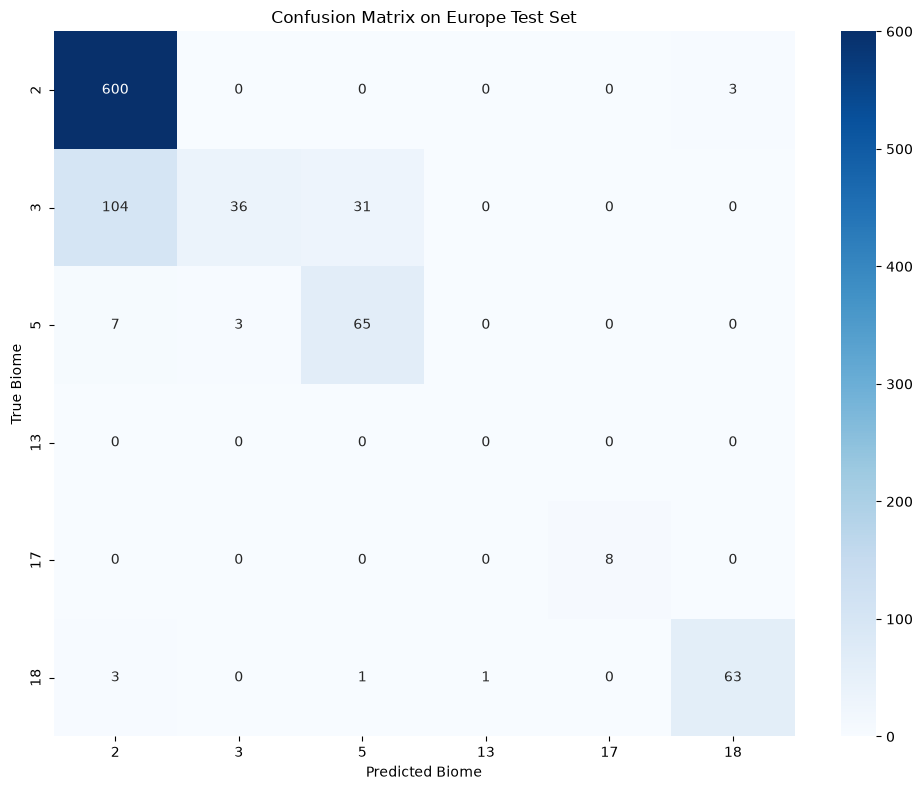

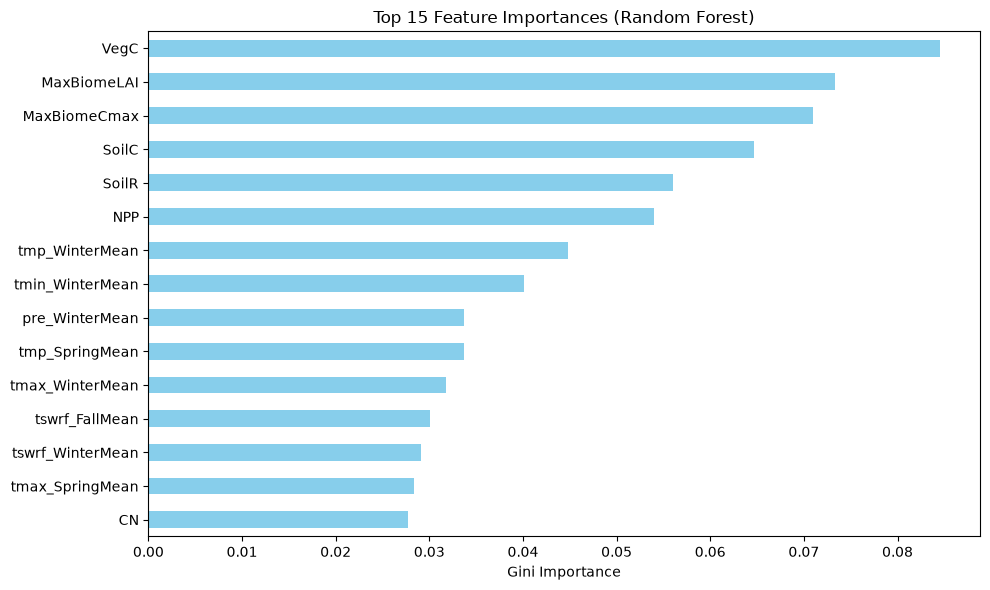

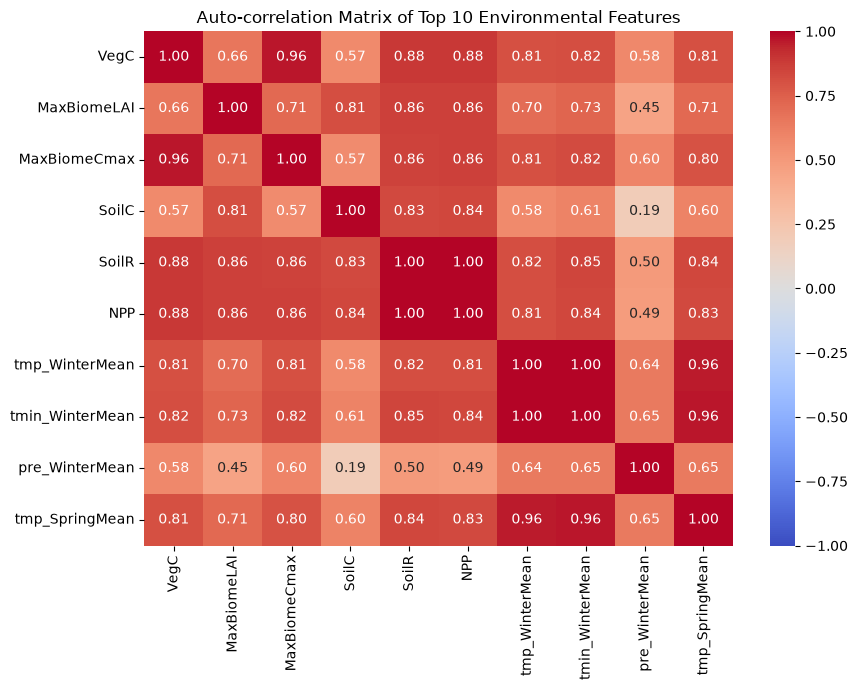


Top 10 Feature Importances List:
VegC               0.0846
MaxBiomeLAI        0.0733
MaxBiomeCmax       0.0709
SoilC              0.0647
SoilR              0.0560
NPP                0.0540
tmp_WinterMean     0.0448
tmin_WinterMean    0.0401
pre_WinterMean     0.0337
tmp_SpringMean     0.0337
dtype: float64


In [29]:
# 1. Plot Confusion Matrix for Europe Test Set
cm = confusion_matrix(y_test_eur, y_pred_eur)
labels = sorted(list(set(y_test_eur.unique()).union(set(np.unique(y_pred_eur)))))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix on Europe Test Set')
plt.xlabel('Predicted Biome')
plt.ylabel('True Biome')
plt.tight_layout()
plt.show()

# 2. Extract and Plot Top 15 Feature Importances
importances = pd.Series(best_rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(15).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()

# 3. Section 4.5: Feature Auto-correlation Matrix (Check Collinearity among Top Features)
top_features = importances.head(10).index.tolist()
corr_matrix = X_train_can[top_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Auto-correlation Matrix of Top 10 Environmental Features')
plt.tight_layout()
plt.show()

print("\nTop 10 Feature Importances List:")
print(importances.head(10).round(4))

In [30]:
#Canada model training

exclude_cols = [
    'NPP', 'VegC',
    'LitterC', 'SoilC', 'SoilR', 
    'Biome_Cmax', 
    'Biome_LAI', 
    'MaxBiomeCmax', 
    'MaxBiomeLAI',
    'GFED-region', 'UN', 'Ecoregion',
#    'tswf_WinterMean','tswf_SummerMean','tswf_FallMean','tswf_SpringMean',
 #   'tmax_SprintMean','tmax_WinterMean','tmin_SpringMean','tmin_WinterMean',
#'tmax_SummerMean', 'tmax_FallMean', 'tmin_SummerMean','tmin_FallMean'
]
df_can_clean = clean_dataset(df_canada)

clean_features = [col for col in X_train_can.columns if col not in exclude_cols]

X_train_clean = X_train_can[clean_features]
X_test_clean = X_test_eur[clean_features]

y_train_npp = df_can_clean['NPP']
y_test_npp = df_eur_clean['NPP']

y_train_vegc = df_can_clean['VegC']
y_test_vegc = df_eur_clean['VegC']



In [31]:
#param_grid = {
#    'n_estimators': [100, 200],
#    'max_depth': [10, 20, None],
#    'min_samples_leaf': [1, 2, 4],
#}


#print("=" * 60)
#print("Starting GridSearchCV for NPP Model...")
#grid_npp = GridSearchCV(
#    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
#    param_grid=param_grid,
#    cv=5,
#    scoring='r2',
#    n_jobs=-1,
#)
#grid_npp.fit(X_train_clean, y_train_npp)

#print("Best NPP Hyperparameters:", grid_npp.best_params_)
#print(f"Best NPP CV R² Score: {grid_npp.best_score_:.4f}\n")


#best_rf_npp = grid_npp.best_estimator_


#print("=" * 60)
#print("Starting GridSearchCV for VegC Model...")
#grid_vegc = GridSearchCV(
#    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
#    param_grid=param_grid,
#    cv=5,
#    scoring='r2',
#    n_jobs=-1,
#)
#grid_vegc.fit(X_train_clean, y_train_vegc)

#print("Best VegC Hyperparameters:", grid_vegc.best_params_)
#print(f"Best VegC CV R² Score: {grid_vegc.best_score_:.4f}\n")

#best_rf_vegc = grid_vegc.best_estimator_

In [32]:
rf_npp = RandomForestRegressor(n_estimators=200, max_depth=None,min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_vegc = RandomForestRegressor(n_estimators=200, max_depth=10,min_samples_leaf=10, random_state=42, n_jobs=-1)

rf_npp.fit(X_train_clean, y_train_npp)
rf_vegc.fit(X_train_clean, y_train_vegc)

pred_npp = rf_npp.predict(X_test_clean)
pred_vegc = rf_vegc.predict(X_test_clean)

 Canada Regression Model on EU Evaluation
--- NPP RF Regression (Europe Test Set) ---
R² Score : 0.5258
RMSE     : 0.0921
MAE      : 0.0632

--- VegC RF Regression (Europe Test Set) ---
R² Score : 0.3756
RMSE     : 2.3272
MAE      : 1.8474



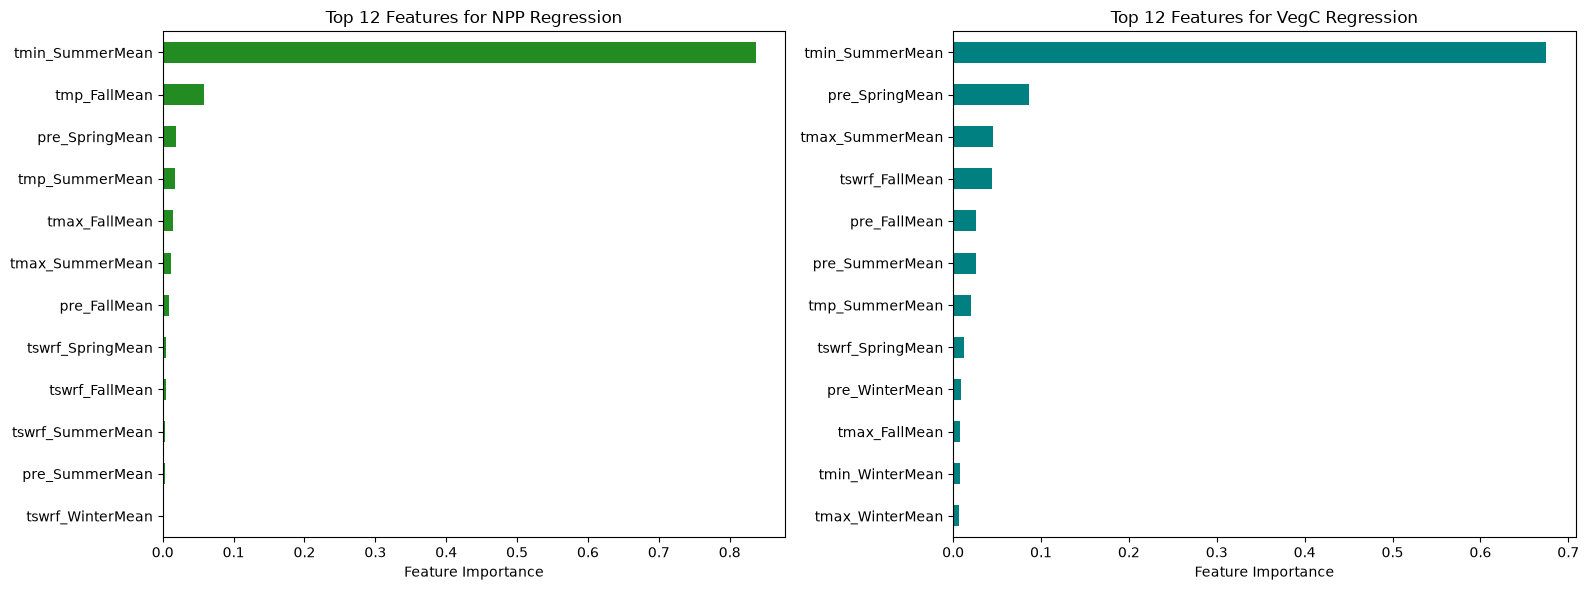

In [33]:
def evaluate_regression(y_true, y_pred, target_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"--- {target_name} RF Regression (Europe Test Set) ---")
    print(f"R² Score : {r2:.4f}")
    print(f"RMSE     : {rmse:.4f}")
    print(f"MAE      : {mae:.4f}\n")
    return r2, rmse, mae

print("=" * 60)
print(" Canada Regression Model on EU Evaluation")
print("=" * 60)
r2_npp, rmse_npp, mae_npp = evaluate_regression(y_test_npp, pred_npp, "NPP")
r2_vegc, rmse_vegc, mae_vegc = evaluate_regression(y_test_vegc, pred_vegc, "VegC")

imp_npp = pd.Series(rf_npp.feature_importances_, index=clean_features).sort_values(ascending=False)
imp_vegc = pd.Series(rf_vegc.feature_importances_, index=clean_features).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_npp.head(12).plot(kind='barh', ax=axes[0], color='forestgreen')
axes[0].invert_yaxis()
axes[0].set_title('Top 12 Features for NPP Regression')
axes[0].set_xlabel('Feature Importance')

imp_vegc.head(12).plot(kind='barh', ax=axes[1], color='teal')
axes[1].invert_yaxis()
axes[1].set_title('Top 12 Features for VegC Regression')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

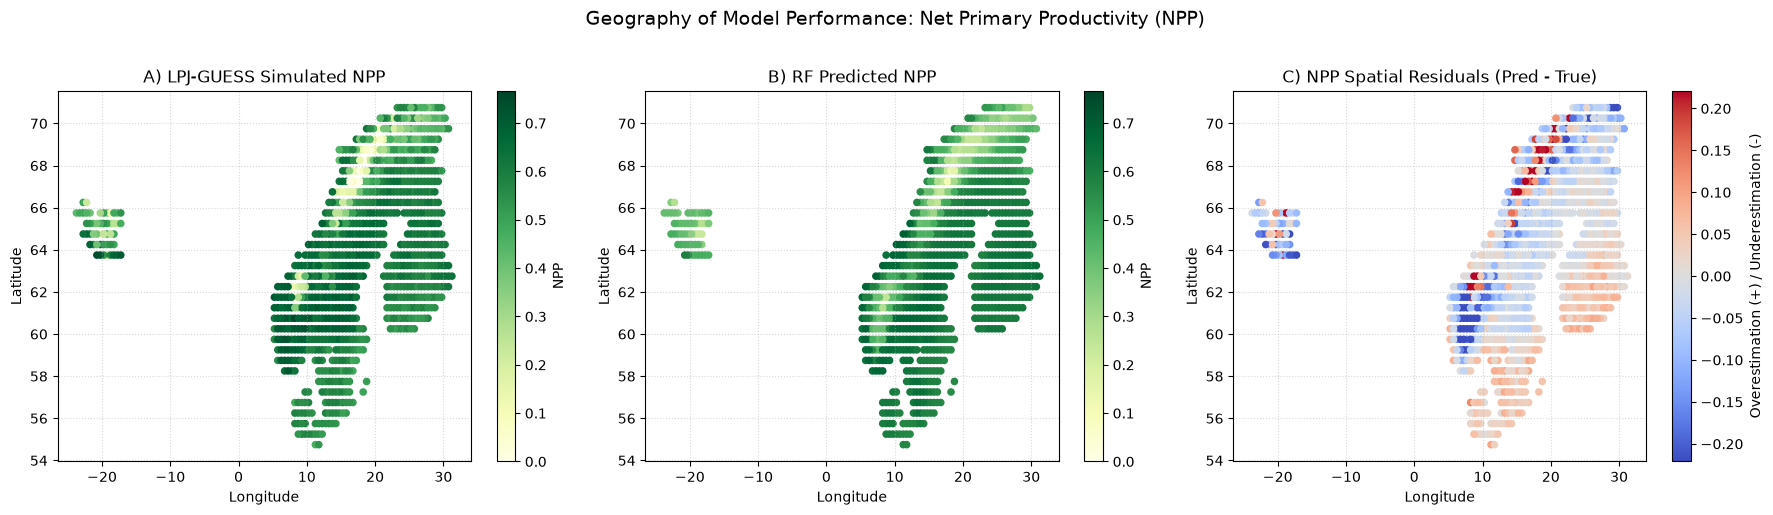

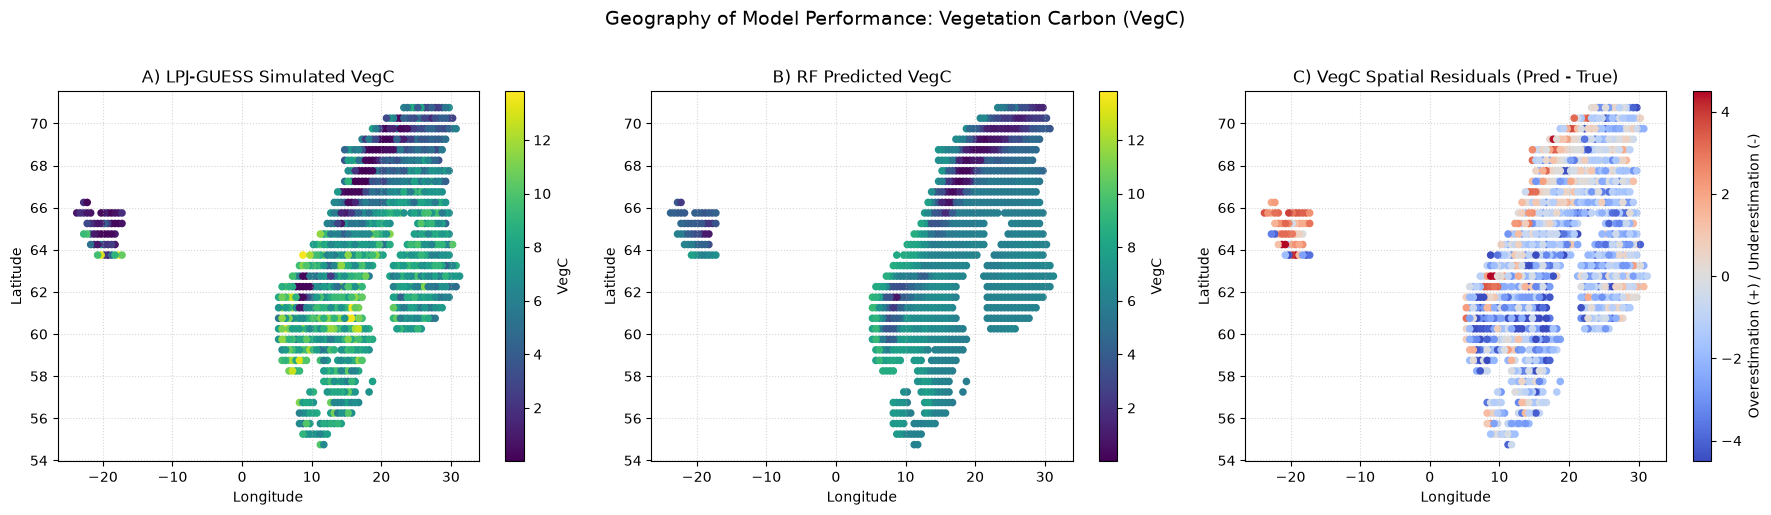

In [34]:

#draw effect plot
lon_col = 'Lon' if 'Lon' in df_eur_clean.columns else 'longitude'
lat_col = 'Lat' if 'Lat' in df_eur_clean.columns else 'latitude'

df_map = df_eur_clean[[lon_col, lat_col]].copy()

df_map['NPP_True'] = y_test_npp
df_map['NPP_Pred'] = pred_npp
df_map['NPP_Residual'] = pred_npp - y_test_npp 
df_map['VegC_True'] = y_test_vegc
df_map['VegC_Pred'] = pred_vegc
df_map['VegC_Residual'] = pred_vegc - y_test_vegc


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc1 = axes[0].scatter(df_map[lon_col], df_map[lat_col], c=df_map['NPP_True'], cmap='YlGn', s=20)
axes[0].set_title('A) LPJ-GUESS Simulated NPP')
plt.colorbar(sc1, ax=axes[0], label='NPP')

sc2 = axes[1].scatter(df_map[lon_col], df_map[lat_col], c=df_map['NPP_Pred'], cmap='YlGn', s=20,
                      vmin=df_map['NPP_True'].min(), vmax=df_map['NPP_True'].max())
axes[1].set_title('B) RF Predicted NPP')
plt.colorbar(sc2, ax=axes[1], label='NPP')

vbound_npp = np.abs(df_map['NPP_Residual']).quantile(0.95)
sc3 = axes[2].scatter(df_map[lon_col], df_map[lat_col], c=df_map['NPP_Residual'], cmap='coolwarm', s=20,
                      vmin=-vbound_npp, vmax=vbound_npp)
axes[2].set_title('C) NPP Spatial Residuals (Pred - True)')
plt.colorbar(sc3, ax=axes[2], label='Overestimation (+) / Underestimation (-)')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Geography of Model Performance: Net Primary Productivity (NPP)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc1 = axes[0].scatter(df_map[lon_col], df_map[lat_col], c=df_map['VegC_True'], cmap='viridis', s=20)
axes[0].set_title('A) LPJ-GUESS Simulated VegC')
plt.colorbar(sc1, ax=axes[0], label='VegC')

sc2 = axes[1].scatter(df_map[lon_col], df_map[lat_col], c=df_map['VegC_Pred'], cmap='viridis', s=20,
                      vmin=df_map['VegC_True'].min(), vmax=df_map['VegC_True'].max())
axes[1].set_title('B) RF Predicted VegC')
plt.colorbar(sc2, ax=axes[1], label='VegC')

vbound_vegc = np.abs(df_map['VegC_Residual']).quantile(0.95)
sc3 = axes[2].scatter(df_map[lon_col], df_map[lat_col], c=df_map['VegC_Residual'], cmap='coolwarm', s=20,
                      vmin=-vbound_vegc, vmax=vbound_vegc)
axes[2].set_title('C) VegC Spatial Residuals (Pred - True)')
plt.colorbar(sc3, ax=axes[2], label='Overestimation (+) / Underestimation (-)')

for ax in axes:
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Geography of Model Performance: Vegetation Carbon (VegC)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [35]:
#Training model in South America, test in australia
exclude_cols = [
    'NPP', 'VegC', 'LitterC', 'SoilC', 'SoilR', 
    'Biome_obs', 'Biome_Cmax', 'Biome_LAI', 
    'MaxBiomeCmax', 'MaxBiomeLAI',
    'GFED-region', 'UN', 'Ecoregion', 'Lon', 'Lat', 'longitude', 'latitude'
]



clean_features = [col for col in df_south_america.columns if col not in exclude_cols]

X_train_sa = df_south_america[clean_features]
X_test_au = df_australia[clean_features]


y_train_biome = df_south_america['Biome_obs']
y_test_biome = df_australia['Biome_obs']

y_train_npp = df_south_america['NPP']
y_test_npp = df_australia['NPP']

y_train_vegc = df_south_america['VegC']
y_test_vegc = df_australia['VegC']




clf_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_rf.fit(X_train_sa, y_train_biome)
pred_biome = clf_rf.predict(X_test_au)

print("\n" + "="*60)
print("Biome Classification Report: South America -> Australia")
print("="*60)
print(classification_report(y_test_biome, pred_biome, zero_division=0))



reg_npp = RandomForestRegressor(
    n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1
)
reg_npp.fit(X_train_sa, y_train_npp)
pred_npp = reg_npp.predict(X_test_au)

r2_npp = r2_score(y_test_npp, pred_npp)
rmse_npp = np.sqrt(mean_squared_error(y_test_npp, pred_npp))
mae_npp = mean_absolute_error(y_test_npp, pred_npp)




reg_vegc = RandomForestRegressor(
    n_estimators=100, max_features='sqrt', random_state=42, n_jobs=-1
)
reg_vegc.fit(X_train_sa, y_train_vegc)
pred_vegc = reg_vegc.predict(X_test_au)

r2_vegc = r2_score(y_test_vegc, pred_vegc)
rmse_vegc = np.sqrt(mean_squared_error(y_test_vegc, pred_vegc))
mae_vegc = mean_absolute_error(y_test_vegc, pred_vegc)

print("\n" + "="*60)
print("Regression Model Evaluation: South America -> Australia")
print("="*60)
print(f"--- NPP RF Regression ---")
print(f"R² Score : {r2_npp:.4f}")
print(f"RMSE     : {rmse_npp:.4f}")
print(f"MAE      : {mae_npp:.4f}\n")

print(f"--- VegC RF Regression ---")
print(f"R² Score : {r2_vegc:.4f}")
print(f"RMSE     : {rmse_vegc:.4f}")
print(f"MAE      : {mae_vegc:.4f}")


Biome Classification Report: South America -> Australia
              precision    recall  f1-score   support

           2       1.00      1.00      1.00         1
           3       0.56      0.62      0.59         8
           5       0.69      0.58      0.63        19
           6       0.62      0.99      0.77       152
           7       0.00      0.00      0.00         5
           8       0.63      0.63      0.63        51
           9       1.00      0.50      0.67         6
          10       0.80      0.04      0.09        89
          11       0.21      0.90      0.35       202
          12       0.31      0.37      0.34       593
          13       0.00      0.00      0.00         3
          14       0.67      0.00      0.01       436
          15       0.24      0.11      0.15       144
          16       0.77      0.59      0.67      1117

    accuracy                           0.46      2826
   macro avg       0.53      0.45      0.42      2826
weighted avg       0.58

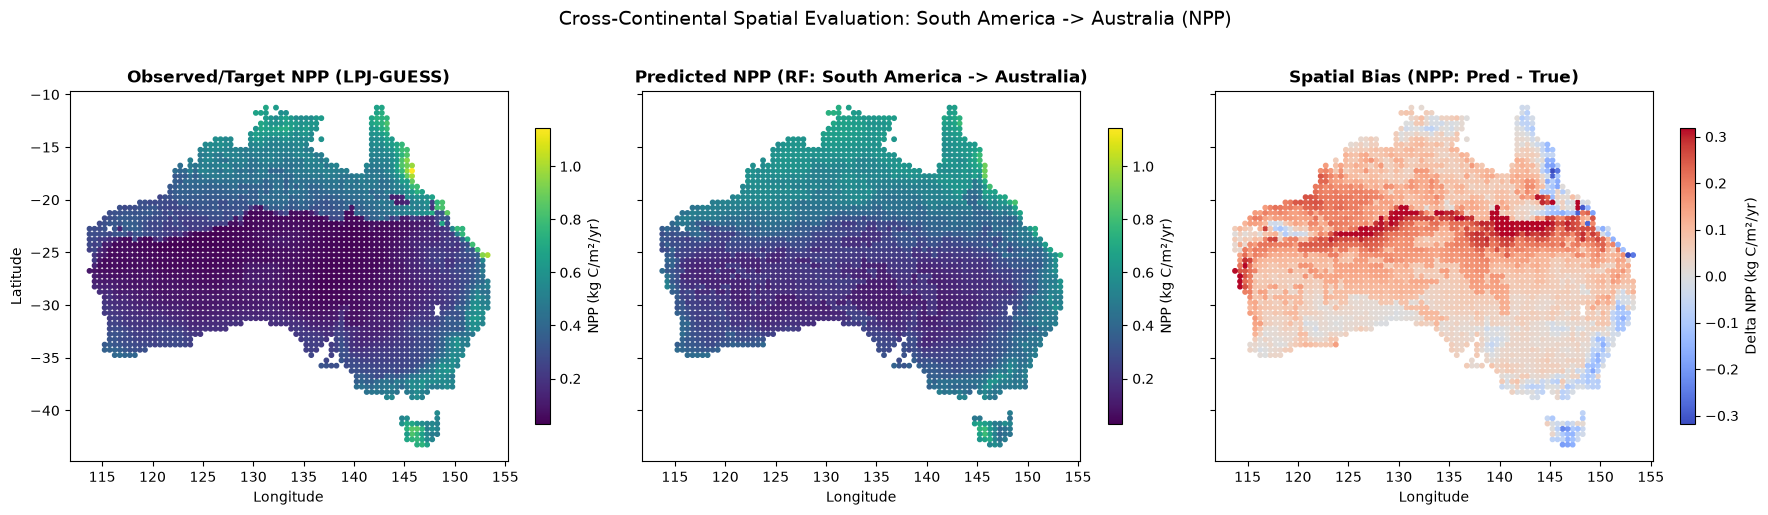

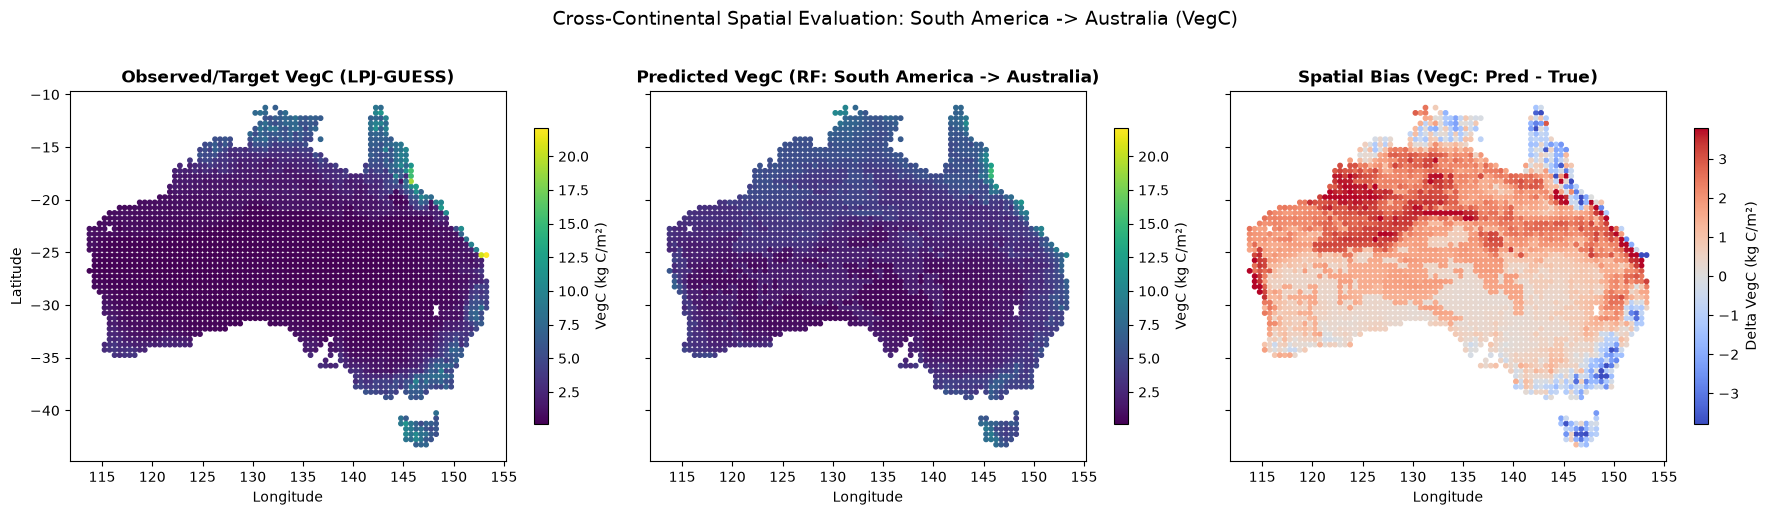

In [36]:
lon_col = 'Lon' if 'Lon' in df_australia.columns else ('longitude' if 'longitude' in df_australia.columns else None)
lat_col = 'Lat' if 'Lat' in df_australia.columns else ('latitude' if 'latitude' in df_australia.columns else None)

lons = df_australia[lon_col]
lats = df_australia[lat_col]

def plot_spatial_comparison(lons, lats, y_true, y_pred, var_name, unit=""):
    diff = y_pred - y_true  

    vmin = min(y_true.min(), y_pred.min())
    vmax = max(y_true.max(), y_pred.max())
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
    

    sc1 = axes[0].scatter(lons, lats, c=y_true, cmap='viridis', s=10, vmin=vmin, vmax=vmax)
    axes[0].set_title(f'Observed/Target {var_name} (LPJ-GUESS)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    plt.colorbar(sc1, ax=axes[0], label=f'{var_name} {unit}', shrink=0.8)
    

    sc2 = axes[1].scatter(lons, lats, c=y_pred, cmap='viridis', s=10, vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Predicted {var_name} (RF: South America -> Australia)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Longitude')
    plt.colorbar(sc2, ax=axes[1], label=f'{var_name} {unit}', shrink=0.8)
    

    max_abs_diff = np.percentile(np.abs(diff), 98)
    sc3 = axes[2].scatter(lons, lats, c=diff, cmap='coolwarm', s=10, vmin=-max_abs_diff, vmax=max_abs_diff)
    axes[2].set_title(f'Spatial Bias ({var_name}: Pred - True)', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Longitude')
    plt.colorbar(sc3, ax=axes[2], label=f'Delta {var_name} {unit}', shrink=0.8)
    
    plt.suptitle(f'Cross-Continental Spatial Evaluation: South America -> Australia ({var_name})', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_spatial_comparison(lons, lats, y_test_npp, pred_npp, var_name="NPP", unit="(kg C/m²/yr)")


plot_spatial_comparison(lons, lats, y_test_vegc, pred_vegc, var_name="VegC", unit="(kg C/m²)")

In [37]:
#train in Canada, test in australia (NPP and VegC)
features = [
    'tmp_SpringMean', 'tmp_SummerMean', 'tmp_FallMean', 'tmp_WinterMean',
    'pre_SpringMean', 'pre_SummerMean', 'pre_FallMean', 'pre_WinterMean',
    'tswrf_SpringMean', 'tswrf_SummerMean', 'tswrf_FallMean', 'tswrf_WinterMean'
]
targets = ['NPP', 'VegC']

X_train, y_train = df_canada[features], df_canada[targets]
X_test, y_test = df_australia[features], df_australia[targets]


rf_model = RandomForestRegressor(n_estimators=200, max_depth=20,min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
y_pred_df = pd.DataFrame(y_pred, columns=targets, index=y_test.index)

print("=== Canada-->Australia===")
for target in targets:
    r2 = r2_score(y_test[target], y_pred_df[target])
    rmse = np.sqrt(mean_squared_error(y_test[target], y_pred_df[target]))
    mae = mean_absolute_error(y_test[target], y_pred_df[target])
    print(f"[{target}] R²: {r2:.3f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")




=== Canada-->Australia===
[NPP] R²: -1.633 | RMSE: 0.3142 | MAE: 0.2798
[VegC] R²: -2.346 | RMSE: 4.1435 | MAE: 3.8969
